# 第063讲 提升树的实际训练

按顺序运行。先做Newton叶值手算，再执行五角色实验和显式测试。所有数据为原创合成；无需联网。

In [1]:
from pathlib import Path
import json, numpy as np
from IPython.display import display, Image
from boosting import derivatives, leaf_weight, split_gain
from experiment import run
from plots import build
from common import write_json
print('第063讲，输出保存到 outputs/notebook')

第063讲，输出保存到 outputs/notebook


## 手算核对
初始logit为0，先预测每行梯度/Hessian及左右叶值。

In [2]:
g,h=derivatives([0,0,1,1],[0,0,0,0])
print('梯度:',g,'Hessian:',h)
print('lambda=1左叶:',leaf_weight(1,.5,1))
print('lambda=1分裂增益:',split_gain(1,.5,-1,.5,1))

梯度: [ 0.5  0.5 -0.5 -0.5] Hessian: [0.25 0.25 0.25 0.25]
lambda=1左叶: -0.6666666666666666
lambda=1分裂增益: 0.6666666666666666


## 真正运行训练
训练、早停、调参、校准和测试的职责独立。结果保存到新目录。

In [3]:
result=run()
write_json('outputs/notebook/result.json',result)
print(json.dumps({'splits':result['split_sizes'],'selected':result['selected_hist_index'],'test':result['test']},ensure_ascii=False,indent=2))

{
  "splits": {
    "train": 480,
    "stop": 120,
    "tune": 160,
    "calibration": 160,
    "test": 240
  },
  "selected": 2,
  "test": {
    "hist_raw": {
      "log_loss": 0.5887542774777809,
      "brier": 0.20119238443052798,
      "auc": 0.7544109474854126,
      "accuracy": 0.6958333333333333
    },
    "hist_sigmoid": {
      "log_loss": 0.591922840743995,
      "brier": 0.20251128516718828,
      "auc": 0.7544109474854126,
      "accuracy": 0.6958333333333333
    },
    "linear": {
      "log_loss": 0.6313309524799041,
      "brier": 0.22033937378102053,
      "auc": 0.6995693248124479,
      "accuracy": 0.6708333333333333
    }
  }
}


In [4]:
for row in result['hist_candidates']:
    print(row['index'],row['config'],'停止轮数',row['iterations'],'调参损失',round(row['tune_log_loss'],6))
print('校准参数:', result['calibrator'])

0 {'learning_rate': 0.05, 'max_leaf_nodes': 7, 'l2_regularization': 0.0} 停止轮数 87 调参损失 0.550952
1 {'learning_rate': 0.05, 'max_leaf_nodes': 15, 'l2_regularization': 1.0} 停止轮数 53 调参损失 0.563969
2 {'learning_rate': 0.1, 'max_leaf_nodes': 7, 'l2_regularization': 1.0} 停止轮数 39 调参损失 0.549512
3 {'learning_rate': 0.1, 'max_leaf_nodes': 15, 'l2_regularization': 4.0} 停止轮数 36 调参损失 0.563683
校准参数: {'coefficient': 1.0734832727908712, 'intercept': 0.10104130719742571, 'fit_split': 'calibration'}


## 生成并嵌入教学图
每张图由刚刚执行的result或已说明的解析公式生成。校准略差的结果必须保留。

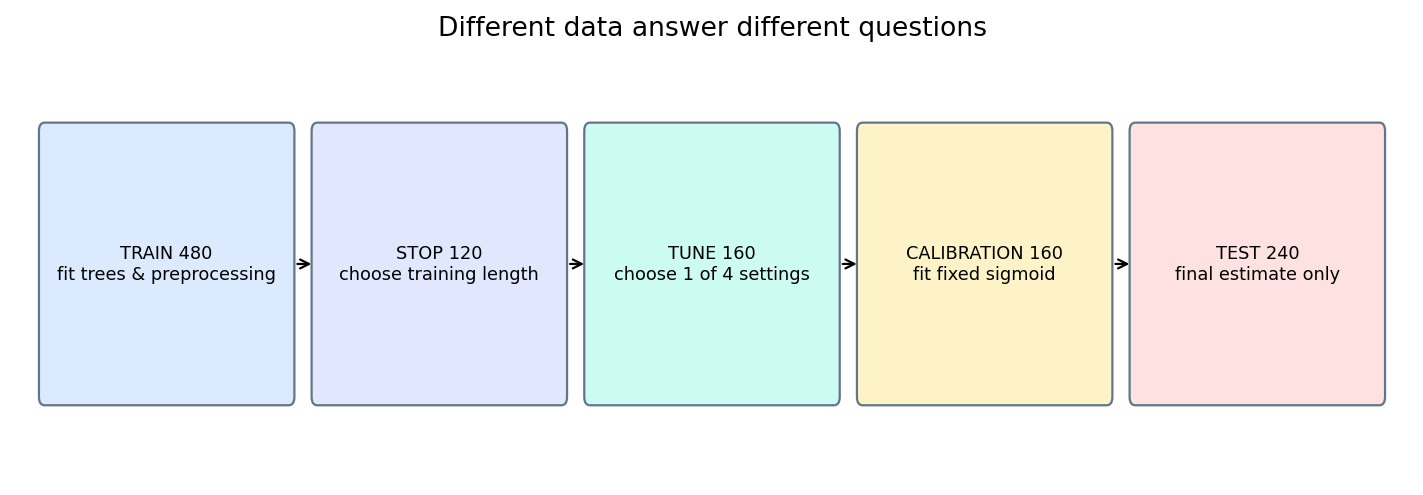

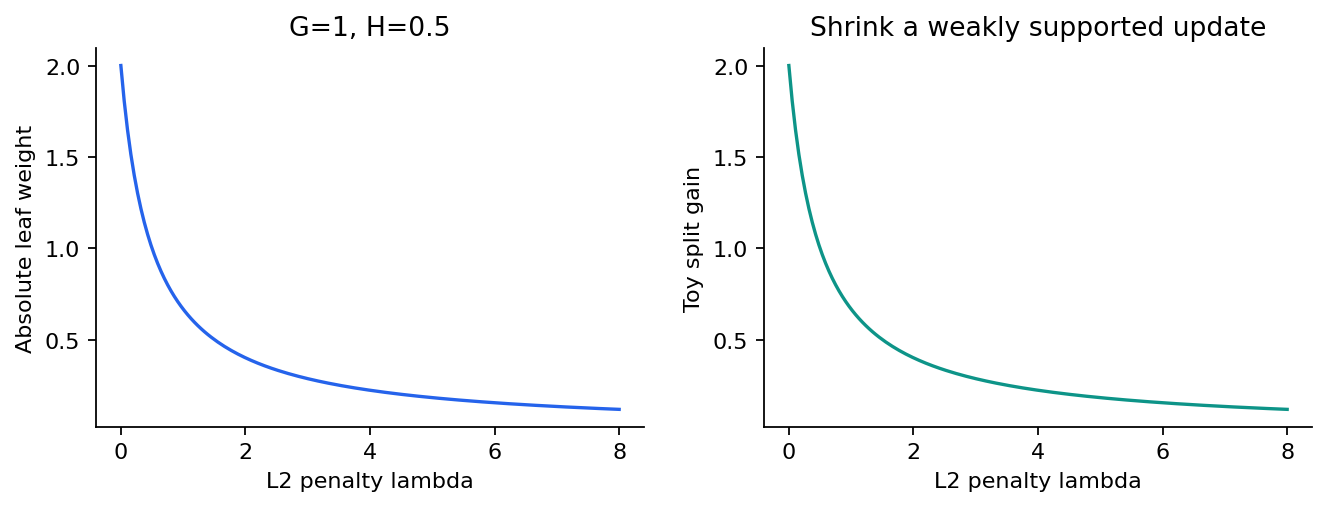

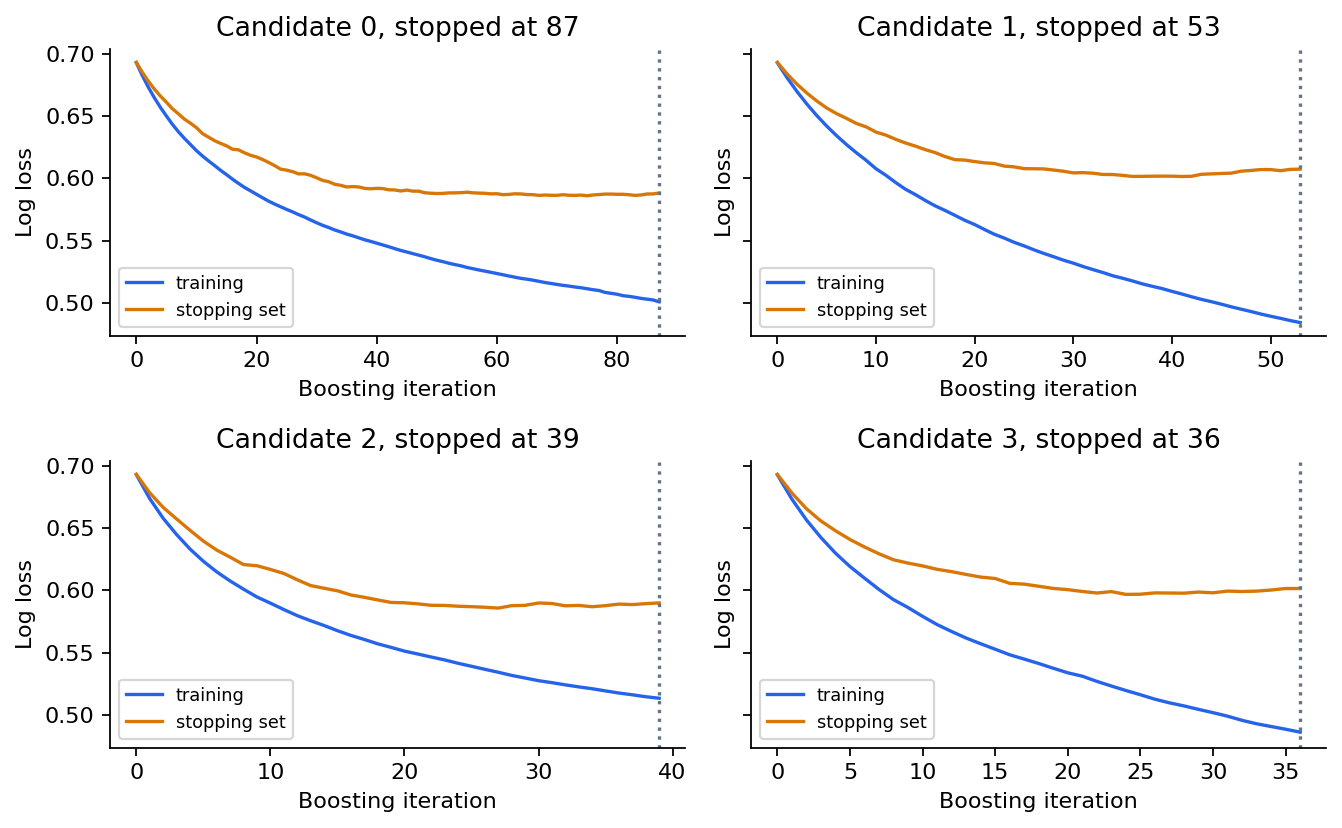

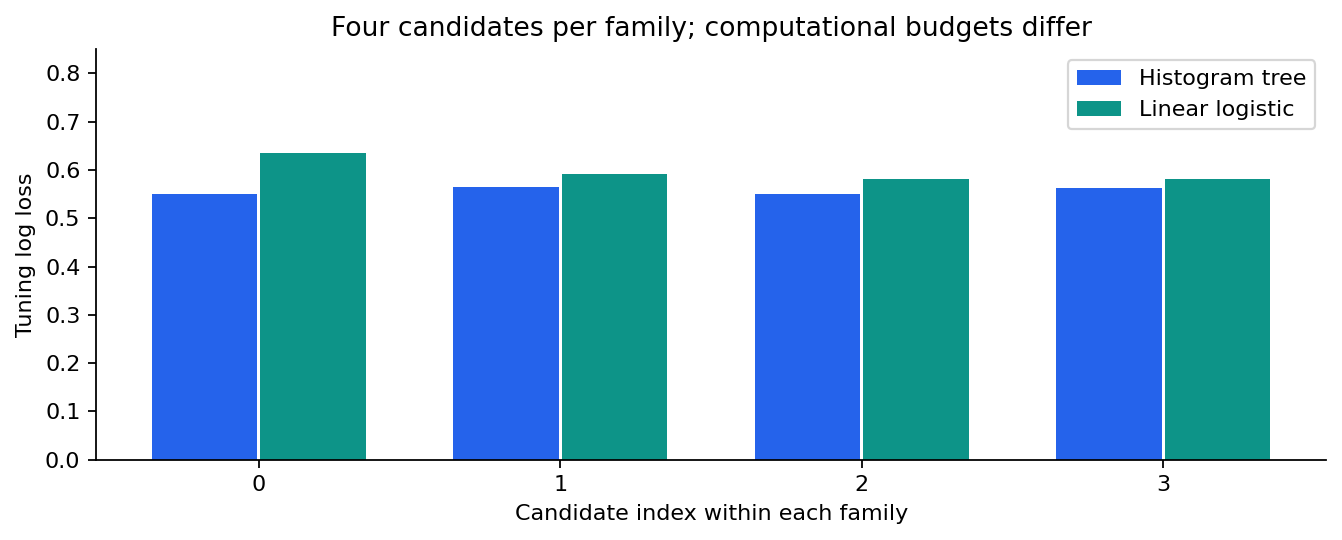

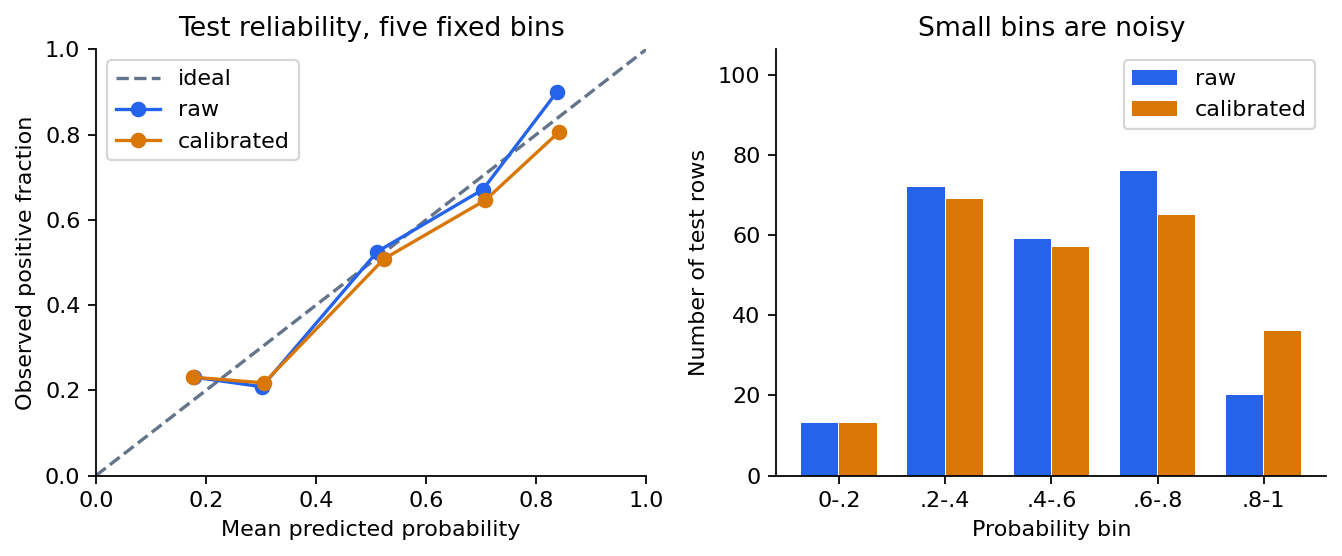

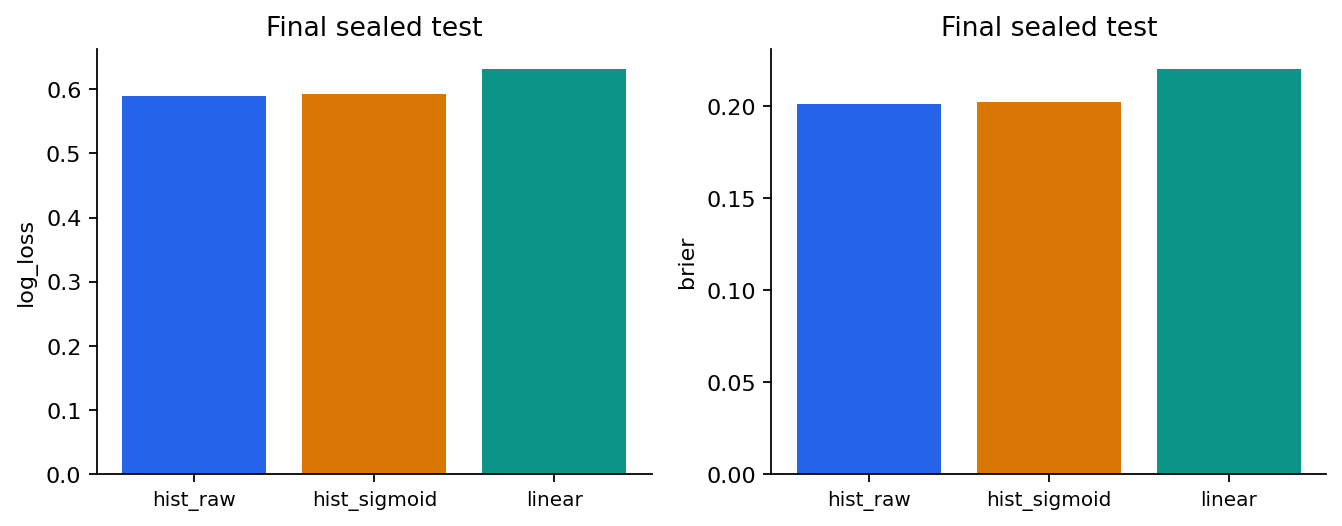

In [5]:
figure_names=build(result,'outputs/notebook/figures')
for name in figure_names:
    display(Image(filename=str(Path('outputs/notebook/figures')/name)))

## 完整测试
这会重新运行独立数值检查和整个实验，普通命令行还应运行-O模式。

In [6]:
from test_experiment import test
verification=test(result)
print({k:v for k,v in verification.items() if k!='check_names'})

{'status': 'passed', 'checks': 325, 'optimized': False, 'fresh_experiment_replayed': True}


## 自己回答
1. 为何父叶分母只加一次lambda？
2. 哪个数据集决定树的轮数？
3. 本次校准变差后，如何设计下一轮研究而不反复使用测试？
详解见answers.pdf。